C:\Users\Nick\AppData\Local\Temp\ipykernel_14740\2224492666.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


   patient_id        icp
0         357  16.545455
1         367   7.557692
2         369   7.096491
3         378   9.310734
4         380  66.333333


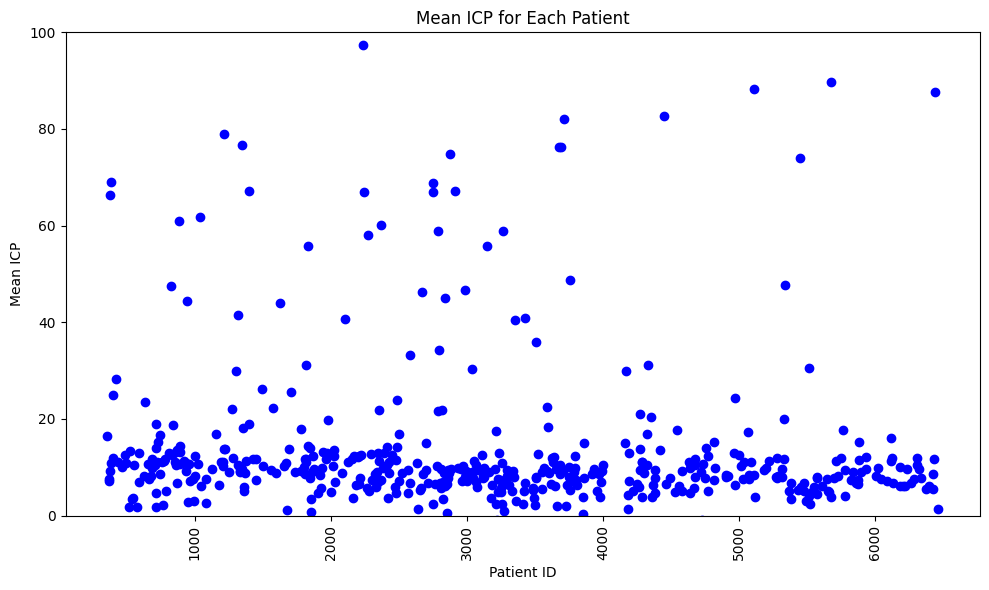

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File path
file_path = r'C:\Users\Nick\Desktop\giteroo\icu-data-analysis\data\nikos_filled_data.csv'

# Read data from CSV file
df = pd.read_csv(file_path)

# Group by 'patient_id' and calculate mean ICP
mean_icp_df = df.groupby('patient_id')['icp'].mean().reset_index()

# Print mean ICP values to verify
print(mean_icp_df.head())

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(mean_icp_df['patient_id'], mean_icp_df['icp'], color='blue')
plt.xlabel('Patient ID')
plt.ylabel('Mean ICP')
plt.title('Mean ICP for Each Patient')
plt.xticks(rotation=90, ha='center')  # Rotate x-axis labels for readability
plt.ylim(0, 100)  # Adjust y-axis limit based on your data range and desired scale
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

class BaselineAdvancedRegressor:
    def __init__(self):
        self.data = pd.DataFrame(columns=['patient_id', 'timestamp', 'icp'])

    def fit(self, X_train, y_train):
        # Concatenate X_train (columns patient_id and timestamp) and y_train (icp)
        X_train = X_train[['patient_id', 'timestamp']]
        self.data = pd.concat([X_train, y_train], axis=1)

    def predict(self, X_test):
        predictions = []

        for index, row in X_test.iterrows():
            patient_id = row['patient_id']
            timestamp = row['timestamp']

            # Filter the training data to include only the rows of the same patient and before the current timestamp
            patient_data = self.data[(self.data['patient_id'] == patient_id) & (self.data['timestamp'] < timestamp)]

            # If there are no previous records, use the overall mean ICP as a fallback
            if patient_data.empty:
                prediction = self.data['icp'].mean()
            else:
                # Calculate the mean ICP value for all previous timestamps
                prediction = patient_data['icp'].mean()

            predictions.append(prediction)

        return predictions



In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Load the data
file_path = r'C:\Users\Nick\Desktop\giteroo\icu-data-analysis\data\final.csv'
df = pd.read_csv(file_path)

# Sort the DataFrame by 'patient_id' and 'timestamp'
df = df.sort_values(by=['patient_id', 'timestamp'])

# Split the data into training and testing sets
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Prepare training and testing sets
X_train = train_df.drop(columns=['icp'])
y_train = train_df['icp']
X_test = test_df.drop(columns=['icp'])
y_test = test_df['icp']


# Initialize and train the Baseline Advanced Regressor
baseline_regressor = BaselineAdvancedRegressor()
baseline_regressor.fit(X_train, y_train)

# Make predictions with the Baseline Advanced Regressor
baseline_predictions = baseline_regressor.predict(test_df)

# For the LinearRegression model, we need to drop the 'timestamp', 'patient_id', and 'date_of_birth' columns

X_train = X_train.drop(columns=['timestamp', 'patient_id', 'date_of_birth'])
X_test = X_test.drop(columns=['timestamp', 'patient_id', 'date_of_birth'])

# Initialize and train the Linear Regression model
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

# Make predictions with the Linear Regression model
linear_predictions = linear_regressor.predict(X_test)

# Evaluate both models
baseline_mse = mean_squared_error(y_test, baseline_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)

print('Baseline Advanced Regressor Mean Squared Error:', baseline_mse)
print('Linear Regression Mean Squared Error:', linear_mse)




Baseline Advanced Regressor Mean Squared Error: 78.99748396317064
Linear Regression Mean Squared Error: 78.46077035693577
